In [6]:
!pip install networkx pandas matplotlib -q

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pickle

In [7]:
from google.colab import files
uploaded = files.upload()
import zipfile, os
if any(f.endswith(".zip") for f in uploaded.keys()):
    zip_name = [f for f in uploaded.keys() if f.endswith(".zip")][0]
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall("ds_jobs_data")
    data_dir = "ds_jobs_data"
else:
    data_dir = "."

print(os.listdir(data_dir))

Saving archive (1).zip to archive (1).zip
['job_postings.csv', 'job_summary.csv', 'job_skills.csv']


In [8]:
postings = pd.read_csv(f"{data_dir}/job_postings.csv")
skills = pd.read_csv(f"{data_dir}/job_skills.csv")

print("job_postings columns:", list(postings.columns))
print("job_skills columns:", list(skills.columns))
postings.head(2)
skills.head(2)

job_postings columns: ['job_link', 'last_processed_time', 'last_status', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']
job_skills columns: ['job_link', 'job_skills']


,job_link,job_skills
0,https://www.linkedin.com/jobs/view/senior-mach...,"Machine Learning, Programming, Python, Scala, ..."
1,https://www.linkedin.com/jobs/view/principal-s...,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,..."


In [9]:
JOIN_KEY = "job_link"
JOB_TITLE_COL = "job_title"
SKILLS_COL = "job_skills"
df = postings.merge(skills, on=JOIN_KEY, how="inner")
print(f"{len(df)} jobs after joining")
df[[JOB_TITLE_COL, SKILLS_COL]].head()

12217 jobs after joining


,job_title,job_skills
0,Senior Machine Learning Engineer,"Machine Learning, Programming, Python, Scala, ..."
1,"Principal Software Engineer, ML Accelerators","C++, Python, PyTorch, TensorFlow, MXNet, CUDA,..."
2,Senior ETL Data Warehouse Specialist,"ETL, Data Integration, Data Transformation, Da..."
3,Senior Data Warehouse Developer / Architect,"Data Lakes, Data Bricks, Azure Data Factory Pi..."
4,Lead Data Engineer,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S..."


In [10]:
SKILL_WHITELIST = {
    "python", "r", "sql", "java", "scala", "c++", "julia",
    "machine learning", "deep learning", "nlp", "computer vision",
    "tensorflow", "pytorch", "keras", "scikit-learn", "mxnet", "cuda",
    "pandas", "numpy", "spark", "hadoop", "hive", "kafka", "airflow",
    "aws", "azure", "gcp", "docker", "kubernetes", "git", "linux",
    "tableau", "power bi", "excel", "matplotlib", "seaborn",
    "statistics", "data visualization", "data analysis", "data engineering",
    "etl", "data warehousing", "big data", "a/b testing", "regression",
    "classification", "clustering", "neural networks", "computer science",
    "mysql", "postgresql", "mongodb", "nosql", "snowflake", "databricks",
    "data modeling", "data mining", "predictive modeling", "time series",
    "communication", "project management", "agile", "leadership",
}

def clean_skills(raw_skill_string):
    if pd.isna(raw_skill_string):
        return []
    parts = [s.strip().lower() for s in str(raw_skill_string).split(",")]
    matched = [s for s in parts if s in SKILL_WHITELIST]
    return list(dict.fromkeys(matched))

df = df.dropna(subset=[JOB_TITLE_COL, SKILLS_COL]).copy()
df["skills_clean"] = df[SKILLS_COL].apply(clean_skills)
df = df[df["skills_clean"].map(len) > 0]
print(f"{len(df)} rows remain after whitelist filtering")
df["skills_clean"].apply(len).describe()

10236 rows remain after whitelist filtering


,skills_clean
count,10236.000000
mean,5.564185
std,4.015515
min,1.000000
25%,2.000000
50%,5.000000
75%,8.000000
max,31.000000


In [11]:
N_JOBS_TO_SAMPLE = 30
RANDOM_SEED = 42

df_sample = df.sample(n=min(N_JOBS_TO_SAMPLE, len(df)), random_state=RANDOM_SEED)
df_sample = df_sample.reset_index(drop=True)
df_sample["job_id"] = [f"job_{i}" for i in range(len(df_sample))]
df_sample[[JOB_TITLE_COL, "skills_clean"]].head()

,job_title,skills_clean
0,"Principal Associate, Data Loss Prevention (DLP...","[agile, aws]"
1,Marketing Data & Analytics Product Owner - Sen...,"[communication, leadership, sql, python, r, ta..."
2,Lead Data Platform Engineer,"[data modeling, data warehousing, etl, machine..."
3,Canvas Consultant (Member Service Specialist) ...,"[leadership, communication]"
4,"Lead Software Engineer, Full Stack (Enterprise...","[python, postgresql, aws, kubernetes, docker, ..."


In [12]:
print(df_sample[df_sample[JOB_TITLE_COL].str.contains("0644", na=False)][[JOB_TITLE_COL, SKILLS_COL]])

                     job_title  \
8  0644 - Développeur Big Data   

                                          job_skills  
8  Big Data, Data Engineering, DataOps, BI, Cloud...  


In [13]:
G = nx.Graph()

for _, row in df_sample.iterrows():
    G.add_node(row["job_id"], bipartite="job", title=row[JOB_TITLE_COL])

all_skills = [s for skills_list in df_sample["skills_clean"] for s in skills_list]
skill_freq = pd.Series(all_skills).value_counts()
max_freq = skill_freq.max()

for _, row in df_sample.iterrows():
    for skill in row["skills_clean"]:
        if skill not in G:
            G.add_node(skill, bipartite="skill")
        weight = round(max_freq / skill_freq[skill], 2)
        G.add_edge(row["job_id"], skill, weight=weight)

n_jobs = sum(1 for _, d in G.nodes(data=True) if d.get("bipartite") == "job")
n_skills = sum(1 for _, d in G.nodes(data=True) if d.get("bipartite") == "skill")
print(f"Graph built: {n_jobs} jobs, {n_skills} skills, {G.number_of_edges()} edges")


Graph built: 30 jobs, 50 skills, 245 edges


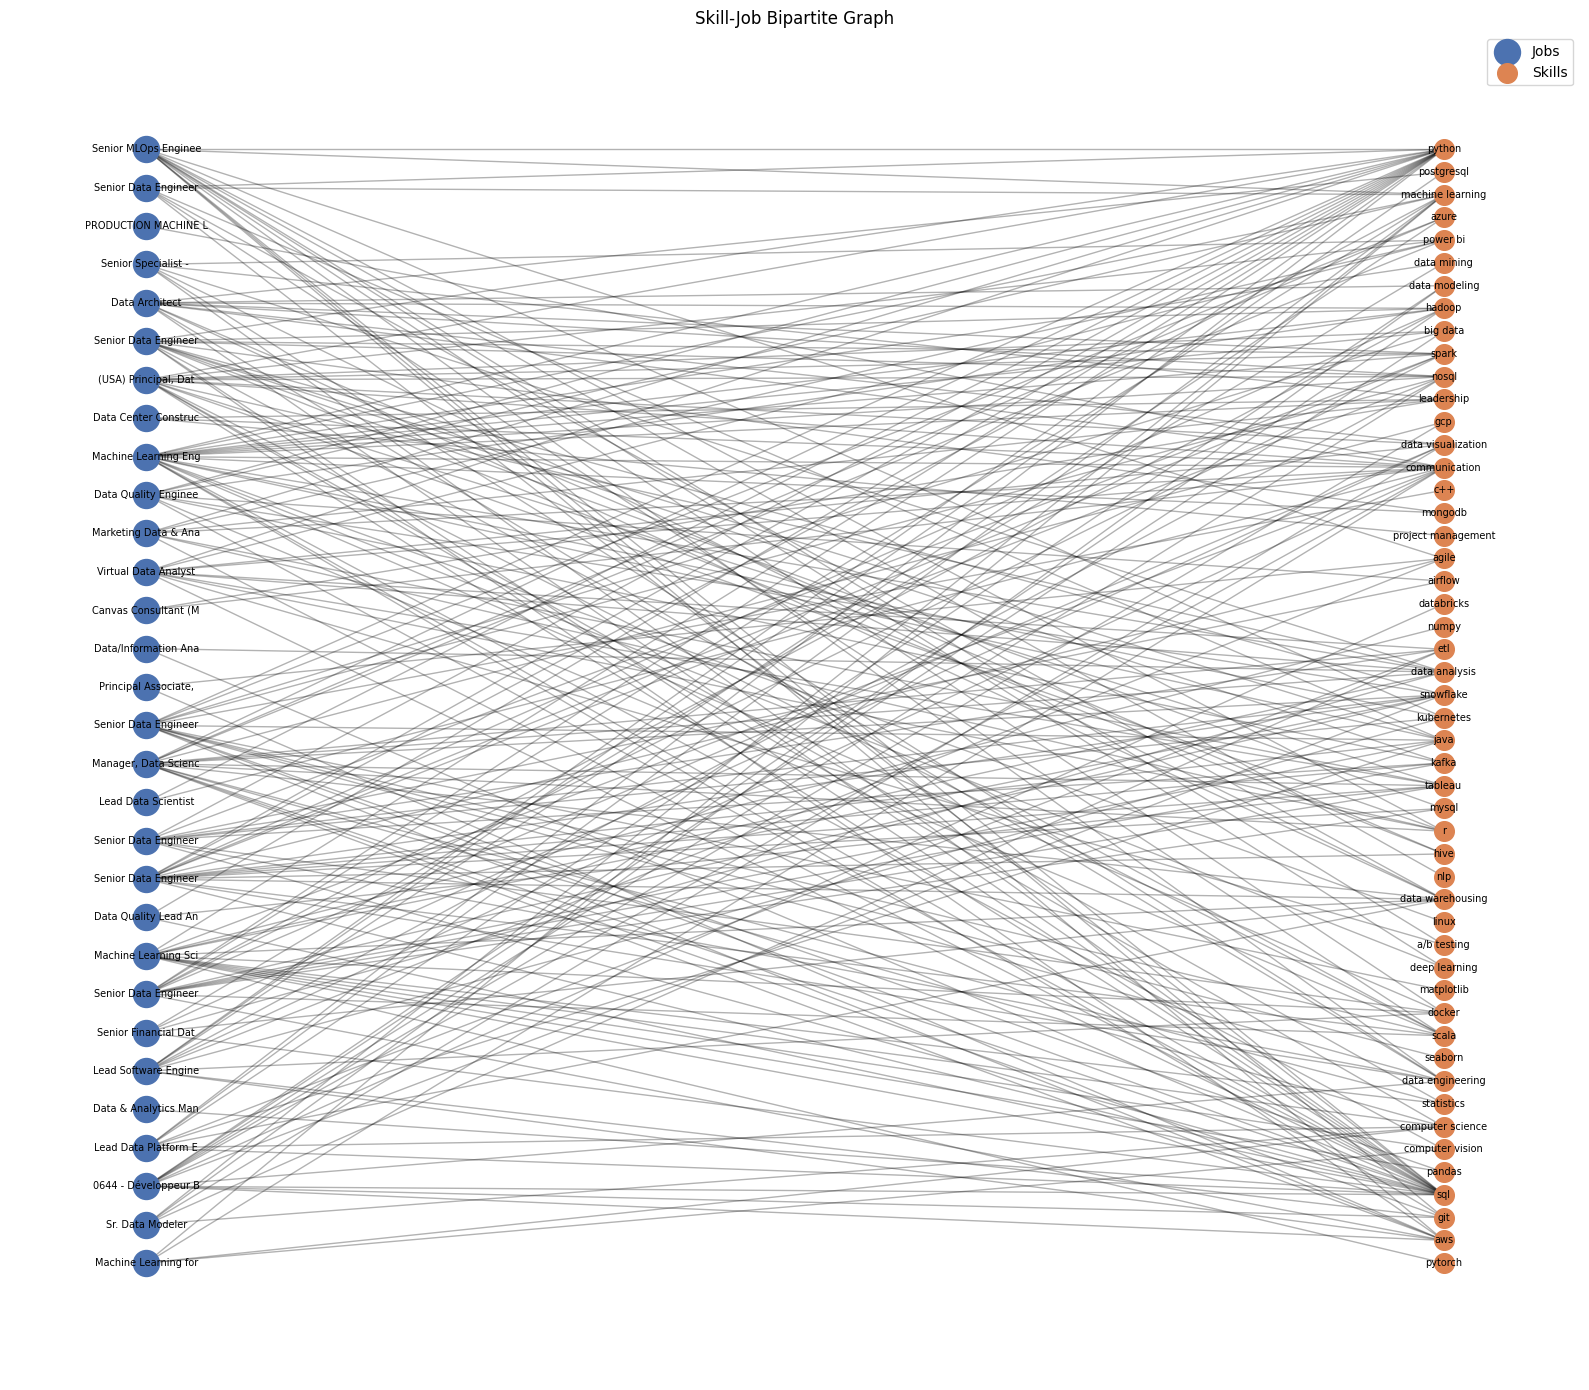

In [14]:
job_nodes = [n for n, d in G.nodes(data=True) if d.get("bipartite") == "job"]
skill_nodes = [n for n, d in G.nodes(data=True) if d.get("bipartite") == "skill"]
pos = nx.bipartite_layout(G, job_nodes)

plt.figure(figsize=(16, 14))
nx.draw_networkx_nodes(G, pos, nodelist=job_nodes, node_color="#4C72B0", node_size=350, label="Jobs")
nx.draw_networkx_nodes(G, pos, nodelist=skill_nodes, node_color="#DD8452", node_size=200, label="Skills")
nx.draw_networkx_edges(G, pos, alpha=0.3)

job_labels = dict(zip(df_sample["job_id"], df_sample[JOB_TITLE_COL].str.slice(0, 20)))
skill_labels = {s: s for s in skill_nodes}
nx.draw_networkx_labels(G, pos, labels={**job_labels, **skill_labels}, font_size=7)

plt.legend(scatterpoints=1)
plt.title("Skill-Job Bipartite Graph")
plt.axis("off")
plt.tight_layout()
plt.savefig("skill_job_bipartite_graph.png", dpi=150)
plt.show()

In [15]:
edges = [{"job_or_skill_1": u, "job_or_skill_2": v, "weight": d["weight"]} for u, v, d in G.edges(data=True)]
pd.DataFrame(edges).to_csv("skill_job_edges.csv", index=False)

with open("skill_job_graph.gpickle", "wb") as f:
    pickle.dump(G, f)

files.download("skill_job_edges.csv")
files.download("skill_job_graph.gpickle")
files.download("skill_job_bipartite_graph.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>